In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
campaigns= pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\python sql and powerbi\campaigns.csv")
customers= pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\python sql and powerbi\customers.csv")
employees = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\python sql and powerbi\employees.csv")
orders = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\python sql and powerbi\orders.csv")
products = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\python sql and powerbi\products.csv")


In [6]:
Tables= {
    "customers":customers,
    "campaigns":campaigns,
    "employees":employees,
    "orders":orders,
    "products":products
    
}

In [7]:
#shape

for name, df in  Tables.items():
    print(f"\n{name}")
    print(df.shape)


customers
(2002, 5)

campaigns
(300, 5)

employees
(300, 4)

orders
(10000, 5)

products
(200, 4)


In [9]:
#missing values
for name, df in Tables.items():
    print(f"\n{name}")
    print(df.isnull().sum())


customers
CustomerID      0
Name            0
Gender        684
City          287
SignupDate      0
dtype: int64

campaigns
CampaignID     0
Channel        0
Spend          0
Clicks         0
Conversions    0
dtype: int64

employees
EmployeeID       0
Department       0
Salary         154
JoiningDate      0
dtype: int64

orders
OrderID       0
CustomerID    0
ProductID     0
Quantity      0
OrderDate     1
dtype: int64

products
ProductID      0
Category       0
ProductName    0
Price          0
dtype: int64


gender missing values 687
city 287
salary 154
it is good to handle categorical missing values with mode or unknown and numerical values with  median which will not be affected by outliers and the columns only needed to drop which has high percentage of missing values 

In [10]:
customers["City"]=customers["City"].fillna("Unknown")

In [11]:
employees["Salary"]=employees["Salary"].fillna(employees["Salary"].median())

for gender first see how much percentage columns are missing then we will decide either to drop or replace it with mode or unknown

In [13]:
customers.drop(columns=["Gender"],inplace=True)

In [12]:
customers.isnull().mean()*100
employees.isnull().mean() * 100

EmployeeID     0.0
Department     0.0
Salary         0.0
JoiningDate    0.0
dtype: float64

In [14]:
#missing values
for name, df in Tables.items():
    print(f"\n{name}")
    print(df.isnull().sum())


customers
CustomerID    0
Name          0
City          0
SignupDate    0
dtype: int64

campaigns
CampaignID     0
Channel        0
Spend          0
Clicks         0
Conversions    0
dtype: int64

employees
EmployeeID     0
Department     0
Salary         0
JoiningDate    0
dtype: int64

orders
OrderID       0
CustomerID    0
ProductID     0
Quantity      0
OrderDate     1
dtype: int64

products
ProductID      0
Category       0
ProductName    0
Price          0
dtype: int64


In [18]:
for name, df in Tables.items():
    print(f"\n{name}")
    print("Duplicates:", df.duplicated().sum())




customers
Duplicates: 2

campaigns
Duplicates: 0

employees
Duplicates: 0

orders
Duplicates: 0

products
Duplicates: 0


In [20]:
customers.drop_duplicates(inplace=True)

In [21]:
for name, df in Tables.items():
    print(f"\n{name}")
    print("Duplicates:", df.duplicated().sum())


customers
Duplicates: 0

campaigns
Duplicates: 0

employees
Duplicates: 0

orders
Duplicates: 0

products
Duplicates: 0


In [22]:
for name, df in Tables.items():
    print(f"\n{name}")
    print(df.describe ())


customers
        CustomerID
count  2000.000000
mean   1000.500000
std     577.494589
min       1.000000
25%     500.750000
50%    1000.500000
75%    1500.250000
max    2000.000000

campaigns
       CampaignID         Spend        Clicks  Conversions
count  300.000000    300.000000    300.000000   300.000000
mean   150.500000  25514.175433  25157.483333  2525.280000
std     86.746758  13938.787070  14004.145720  1407.622114
min      1.000000   1064.180000   1213.000000    54.000000
25%     75.750000  13631.035000  12679.750000  1304.000000
50%    150.500000  25268.000000  25738.000000  2550.000000
75%    225.250000  36545.197500  36944.500000  3715.750000
max    300.000000  49517.280000  49974.000000  4998.000000

employees
             Salary
count    300.000000
mean    8508.806133
std     2992.024771
min     1221.360000
25%     8779.945000
50%     8779.945000
75%     8779.945000
max    14940.700000

orders
         CustomerID      Quantity
count  10000.000000  10000.000000
mean    1

In [23]:
campaigns["ConversionRate"]=(campaigns["Conversions"]/campaigns["Clicks"]) * 100

In [24]:
campaigns["ConversionRate"].describe()

count    300.000000
mean      20.793706
std       36.083008
min        0.140632
25%        5.000928
50%       10.536728
75%       19.308062
max      334.322679
Name: ConversionRate, dtype: float64

The average conversion rate is 20.8%, but the distribution is highly skewed. The maximum value of 334% suggests potential data quality issues because conversions exceed clicks in some records. These records should be investigated before reporting business metrics.

why salary mean is not displayed?

In [25]:
employees["Salary"].describe()

count      300.000000
mean      8508.806133
std       2992.024771
min       1221.360000
25%       8779.945000
50%       8779.945000
75%       8779.945000
max      14940.700000
Name: Salary, dtype: float64

Noticed:

25% = 8779.945
50% = 8779.945
75% = 8779.945

All three quartiles are exactly the same.

This is unusual and suggests one of these possibilities:

Many missing salaries were filled with the same value (likely the median).
A large number of employees have exactly the same salary.
There may be a data quality issue.

In [26]:
employees["Salary"].value_counts().head(10)

Salary
8779.945     154
12439.000      1
4095.590       1
9571.030       1
4559.350       1
2394.260       1
10600.840      1
12042.910      1
1384.570       1
7857.220       1
Name: count, dtype: int64

The salary distribution shows a strong concentration at 8779.945, which appears to be the imputed median value for missing salaries. This indicates that a large portion of data was missing and replaced using median imputation, which reduces variance and may distort real salary distribution patterns.

In [27]:
#Detecting outliers

Q1= employees["Salary"].quantile(0.25)
Q3= employees["Salary"].quantile(0.75)


IQR = Q3 - Q1 

lower_bound= Q1 - 1.5 * IQR
Upper_bound= Q1 + 1.5 * IQR


employees[(employees["Salary"]<lower_bound) |
          (employees["Salary"]>Upper_bound)]

,EmployeeID,Department,Salary,JoiningDate
2,E003,Ops,9868.83,2024-02-01
3,E004,Sales,14282.88,2025-01-29
10,E011,Finance,7345.29,2022-10-25
13,E014,HR,12330.54,2026-06-10
14,E015,Finance,4804.73,2023-01-23
...,...,...,...,...
289,E290,IT,3763.20,2024-12-31
291,E292,Finance,9143.00,2024-09-02
292,E293,IT,14355.09,2018-08-11
296,E297,Finance,4330.50,2023-07-11


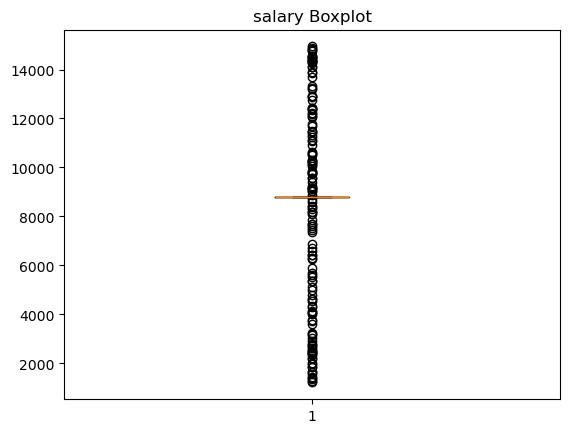

In [28]:
plt.boxplot(employees["Salary"])
plt.title("salary Boxplot")
plt.show()

The salary distribution is heavily concentrated around 8,779 due to median imputation of missing values. Additionally, the presence of multiple outliers on both lower and upper ends indicates high variability in employee compensation and possible data quality issues. The distribution is right-skewed, suggesting a small group of employees earn significantly higher salaries.

In [30]:
for name, df in Tables.items():
    print(f"\n{name}")
    print(df.dtypes)


customers
CustomerID     int64
Name          object
City          object
SignupDate    object
dtype: object

campaigns
CampaignID          int64
Channel            object
Spend             float64
Clicks              int64
Conversions         int64
ConversionRate    float64
dtype: object

employees
EmployeeID      object
Department      object
Salary         float64
JoiningDate     object
dtype: object

orders
OrderID       object
CustomerID     int64
ProductID     object
Quantity       int64
OrderDate     object
dtype: object

products
ProductID       object
Category        object
ProductName     object
Price          float64
dtype: object


In [32]:
for name, df in Tables.items():
    for col in df.columns:
        if "date" in col.lower():
            df[col]=pd.to_datetime(df[col],errors="coerce")

In [33]:
for name, df in Tables.items():
    print(name, df.select_dtypes(include='object').columns)

customers Index(['Name', 'City'], dtype='object')
campaigns Index(['Channel'], dtype='object')
employees Index(['EmployeeID', 'Department'], dtype='object')
orders Index(['OrderID', 'ProductID'], dtype='object')
products Index(['ProductID', 'Category', 'ProductName'], dtype='object')


In [34]:
Tables["employees"]["EmployeeID"].head()

0    E001
1    E002
2    E003
3    E004
4    E005
Name: EmployeeID, dtype: object

In [35]:
Tables["customers"]["City"].unique()

array(['Lahore', 'Peshawar', 'Karachi', 'Multan', 'Faisalabad', 'Unknown',
       'Islamabad'], dtype=object)

In [36]:
#cleaning all text columns by removing extra spaces and converting text to lowercase across all tables in the dataset.

for name, df in Tables.items():
    obj_cols= df.select_dtypes(include='object').columns
    df[obj_cols]= df[obj_cols].apply(lambda x: x.str.strip().str.lower() )



In [37]:
for name, df in Tables.items():
    print("\n", "="*20)
    print(name)
    print("="*20)
    print(df.head())


customers
   CustomerID           Name      City SignupDate
0           1      erik cole    lahore 2024-04-28
1           2  kelly benitez  peshawar 2025-07-24
2           3   holly taylor   karachi 2026-03-18
3           4   brandy davis   karachi        NaT
4           5  nicolas rivas    lahore 2024-11-29

campaigns
   CampaignID                    Channel     Spend  Clicks  Conversions  \
0           1                bennett inc  13037.69   32593         4041   
1           2              jones-spencer   4666.99   28779         2751   
2           3   mason, garcia and cortez  44425.26   39349         2040   
3           4               castro group  35807.70   21575         3065   
4           5  barnes, carter and garcia  17889.15   30588          393   

   ConversionRate  
0       12.398368  
1        9.559053  
2        5.184376  
3       14.206257  
4        1.284818  

employees
  EmployeeID Department     Salary JoiningDate
0       e001      sales   8779.945  2021-01-04
1 

In [ ]:
Tables= {
    "customers":customers,
    "campaigns":campaigns,
    "employees":employees,
    "orders":orders,
    "products":products
}

NameError: name 'Tables' is not defined